# 선형 회귀 모델 - 광고 예산과 판매량 예측

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 1. 데이터 로드

In [2]:
df = pd.read_csv(r'C:\AISOURCE\Homework\dataset\Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 2. 데이터 전처리

In [3]:
# 불필요한 컬럼 제거
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 독립 변수(X)와 종속 변수(y) 설정
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print('X shape:', X.shape)
print('y shape:', y.shape)
df.head()

X shape: (200, 3)
y shape: (200,)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 3. 데이터 분할 (8:2)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'학습 데이터: {X_train.shape[0]}개')
print(f'테스트 데이터: {X_test.shape[0]}개')

학습 데이터: 160개
테스트 데이터: 40개


## 4. 모델 학습

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

print('계수(Coefficients):')
for feature, coef in zip(X.columns, model.coef_):
    print(f'  {feature}: {coef:.4f}')
print(f'절편(Intercept): {model.intercept_:.4f}')

계수(Coefficients):
  TV: 0.0447
  Radio: 0.1892
  Newspaper: 0.0028
절편(Intercept): 2.9791


## 5. 예측

In [6]:
y_pred = model.predict(X_test)

## 6. 모델 평가

In [7]:
r2 = r2_score(y_test, y_pred)
print(f'R-squared (결정계수): {r2:.4f}')

R-squared (결정계수): 0.8994


## 7. 새로운 데이터 예측

In [8]:
new_data = pd.DataFrame({'TV': [200], 'Radio': [50], 'Newspaper': [30]})
new_pred = model.predict(new_data)
print(f'TV=200, Radio=50, Newspaper=30 일 때 예측 판매량: {new_pred[0]:.2f}')

TV=200, Radio=50, Newspaper=30 일 때 예측 판매량: 21.47


## 8. 결과 출력

In [9]:
print('=' * 40)
print(f'테스트 데이터 R-squared: {r2:.4f}')
print(f'새로운 데이터 예측 판매량: {new_pred[0]:.2f}')
print('=' * 40)

테스트 데이터 R-squared: 0.8994
새로운 데이터 예측 판매량: 21.47


## 9. 시각화

C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\1138717127.py:14: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\1138717127.py:14: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\1138717127.py:14: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\1138717127.py:14: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\1138717127.py:14: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\1138717127.py:14: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing fro

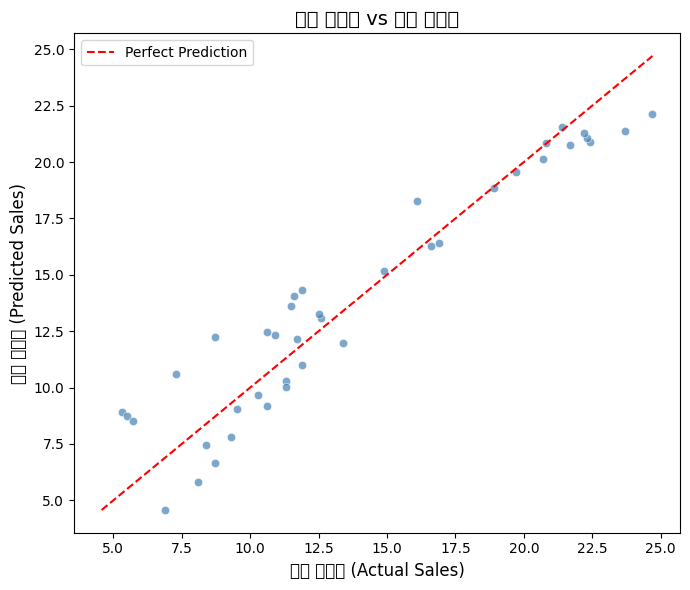

In [10]:
# 실제 판매량 vs 예측 판매량 산점도
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='white', linewidths=0.5)

# 완벽한 예측을 나타내는 대각선
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')

plt.xlabel('실제 판매량 (Actual Sales)', fontsize=12)
plt.ylabel('예측 판매량 (Predicted Sales)', fontsize=12)
plt.title('실제 판매량 vs 예측 판매량', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font

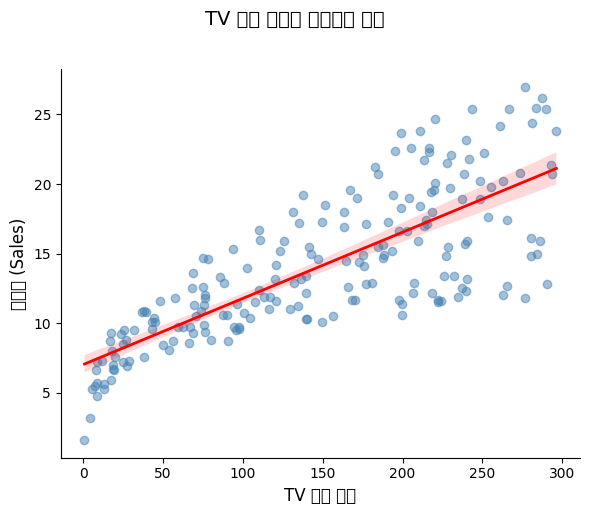

C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font

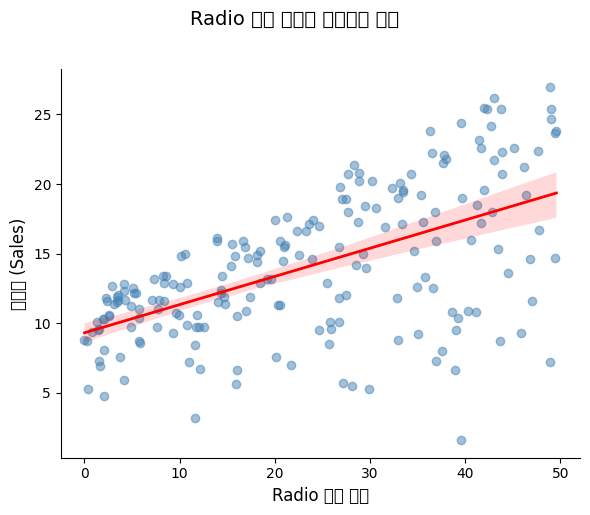

C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\namhe\AppData\Local\Temp\ipykernel_24176\940000013.py:16: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font

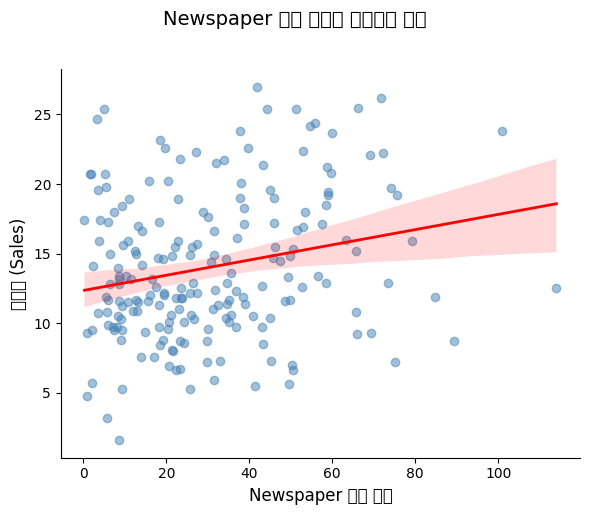

In [11]:
# 각 독립변수와 판매량 관계 시각화 (seaborn lmplot)
features = ['TV', 'Radio', 'Newspaper']

for feature in features:
    g = sns.lmplot(
        data=df,
        x=feature,
        y='Sales',
        height=5,
        aspect=1.2,
        scatter_kws={'alpha': 0.5, 'color': 'steelblue'},
        line_kws={'color': 'red', 'linewidth': 2}
    )
    g.set_axis_labels(feature + ' 광고 예산', '판매량 (Sales)', fontsize=12)
    g.figure.suptitle(f'{feature} 광고 예산과 판매량의 관계', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()